<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/14_multi_agent_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langchain-core langchain-google-genai pydantic tavily-python langsmith -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 894.4 kB/s eta 0:00:00


In [2]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
TAVILY_API_KEY = userdata.get("TAVILY_API_KEY")
LANGSMITH_API_KEY = userdata.get("LANGSMITH_API_KEY")

In [3]:
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "practice"

In [4]:
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from tavily import TavilyClient
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langgraph.types import Command
from dataclasses import dataclass

In [25]:
from langchain.agents import AgentState
from typing import List, Annotated
from langchain_core.messages import BaseMessage
import operator

@dataclass
class CustomState(AgentState):
    messages: Annotated[List[BaseMessage], operator.add] # Explicitly define messages for clarity
    user_name: str
    fav_colour: str

In [26]:
tavily = TavilyClient(api_key=TAVILY_API_KEY)

@tool
def set_username(name: str, runtime: ToolRuntime):
    '''Set Username from the context'''
    return Command(update= {
        'user_name': name,
        'messages': [ToolMessage(content="Username is set", tool_call_id=runtime.tool_call_id)]
    })

@tool
def get_username(runtime: ToolRuntime):
    '''Get Username from the context'''
    try:
        return runtime.state['user_name']
    except KeyError:
        return "Username is not set"

@tool
def search_internet(query: str):
    '''For given user query, search internet and provide answers'''
    return tavily.search(query)

user_tools = [set_username, get_username]
search_tools = [search_internet]

In [27]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    api_key=GOOGLE_API_KEY)
model

ChatGoogleGenerativeAI(profile={}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite', temperature=1.0, client=<google.genai.client.Client object at 0x7bde019f45c0>, default_metadata=(), model_kwargs={})

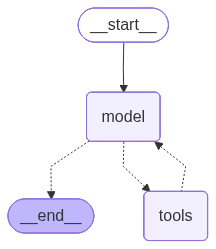

In [28]:
user_subagent = create_agent(
    model=model, tools=user_tools,
    context_schema=CustomState)
user_subagent

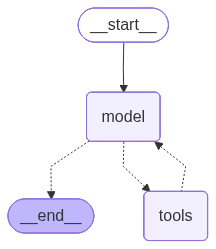

In [29]:
search_subagent = create_agent(
    model=model, tools=search_tools,
    context_schema=CustomState
)
search_subagent

In [30]:
from typing import Optional

@tool
def call_user_subagent(action: str, name: Optional[str] = None):
    '''Invoke User subagent to set or get the user name.
    action: 'set' or 'get'.
    name: (Required for 'set' action) The username to set.
    '''
    if action == "set":
        if not name:
            return "Error: 'name' is required for 'set' action."
        message_content = f"set username to {name}"
    elif action == "get":
        message_content = "what is my username?"
    else:
        return "Error: Invalid action. Must be 'set' or 'get'."

    result = user_subagent.invoke({"messages": [HumanMessage(content=message_content)]})
    return result

In [31]:
@tool
def call_search_subagent(query:str):
    '''Search internet and give response'''
    response = search_subagent.invoke({'messages': [
        SystemMessage(content="You are an helpful assistant who help in searching internet with provided tool and return a curated crsip response"),
        HumanMessage(content=query)
        ]})
    return response

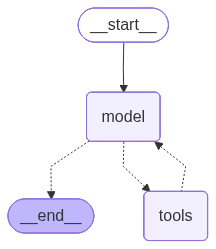

In [32]:
super_agent = create_agent(
    model=model,
    tools=[call_search_subagent, call_user_subagent],
    checkpointer=InMemorySaver(),
    context_schema=CustomState)
super_agent

In [33]:
from pprint import pprint

In [35]:
config = {'configurable': {'thread_id': '3'}}
response = super_agent.invoke(
    {'messages': [HumanMessage("Whats my name?")]},
    config=config)
pprint(response)

{'messages': [HumanMessage(content='Whats my name?', additional_kwargs={}, response_metadata={}, id='3c6897f0-69c5-4628-a080-3c6b4e443ed0'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'call_user_subagent', 'arguments': '{"action": "get"}'}, '__gemini_function_call_thought_signatures__': {'5ee939e6-3e14-4122-a366-11abdaad07fa': 'EjQKMgEMOdbHY5RBEj1fg2Z78bImChW+PwX2GS/pKdgr4Tx3fLwLN+cqdlMz0R18WXcLXWH8'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e1264-e44b-7c11-8fe0-40defb7fcfdc-0', tool_calls=[{'name': 'call_user_subagent', 'args': {'action': 'get'}, 'id': '5ee939e6-3e14-4122-a366-11abdaad07fa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 19, 'total_tokens': 161, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content="{'messages': [HumanMessage(content='what i

In [36]:
response = super_agent.invoke(
    {'messages': [HumanMessage("Me and my friend Tom went to market. Shopkeeper asked me 'What would you like to buy, Thomas?'")]},
    config=config)
pprint(response)

{'messages': [HumanMessage(content='Whats my name?', additional_kwargs={}, response_metadata={}, id='3c6897f0-69c5-4628-a080-3c6b4e443ed0'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'call_user_subagent', 'arguments': '{"action": "get"}'}, '__gemini_function_call_thought_signatures__': {'5ee939e6-3e14-4122-a366-11abdaad07fa': 'EjQKMgEMOdbHY5RBEj1fg2Z78bImChW+PwX2GS/pKdgr4Tx3fLwLN+cqdlMz0R18WXcLXWH8'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e1264-e44b-7c11-8fe0-40defb7fcfdc-0', tool_calls=[{'name': 'call_user_subagent', 'args': {'action': 'get'}, 'id': '5ee939e6-3e14-4122-a366-11abdaad07fa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 19, 'total_tokens': 161, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content="{'messages': [HumanMessage(content='what i

In [37]:
response = super_agent.invoke(
    {'messages': [HumanMessage("Whats my name?")]},
    config=config)
pprint(response)

{'messages': [HumanMessage(content='Whats my name?', additional_kwargs={}, response_metadata={}, id='3c6897f0-69c5-4628-a080-3c6b4e443ed0'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'call_user_subagent', 'arguments': '{"action": "get"}'}, '__gemini_function_call_thought_signatures__': {'5ee939e6-3e14-4122-a366-11abdaad07fa': 'EjQKMgEMOdbHY5RBEj1fg2Z78bImChW+PwX2GS/pKdgr4Tx3fLwLN+cqdlMz0R18WXcLXWH8'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e1264-e44b-7c11-8fe0-40defb7fcfdc-0', tool_calls=[{'name': 'call_user_subagent', 'args': {'action': 'get'}, 'id': '5ee939e6-3e14-4122-a366-11abdaad07fa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 19, 'total_tokens': 161, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content="{'messages': [HumanMessage(content='what i

In [38]:
response = super_agent.invoke(
    {'messages': [
        SystemMessage("Provide a verified response. Format the response with personalized format"),
        HumanMessage("Whos the current CM of Tamil Nadu")]}, config=config)
pprint(response)

{'messages': [HumanMessage(content='Whats my name?', additional_kwargs={}, response_metadata={}, id='3c6897f0-69c5-4628-a080-3c6b4e443ed0'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'call_user_subagent', 'arguments': '{"action": "get"}'}, '__gemini_function_call_thought_signatures__': {'5ee939e6-3e14-4122-a366-11abdaad07fa': 'EjQKMgEMOdbHY5RBEj1fg2Z78bImChW+PwX2GS/pKdgr4Tx3fLwLN+cqdlMz0R18WXcLXWH8'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e1264-e44b-7c11-8fe0-40defb7fcfdc-0', tool_calls=[{'name': 'call_user_subagent', 'args': {'action': 'get'}, 'id': '5ee939e6-3e14-4122-a366-11abdaad07fa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 19, 'total_tokens': 161, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content="{'messages': [HumanMessage(content='what i